In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [3]:
from src.data_loader import load_binance_data
from src.features import add_moving_averages
from src.backtest import run_ma_strategy
from src.metrics import (roi,sharpe_ratio,max_drawdown)

In [4]:
df = load_binance_data()
df = add_moving_averages(df)
df = run_ma_strategy(df)
df.head()

,timestamp,open,high,low,close,volume,ma50,ma200,signal,position,market_return,strategy_return
199,2024-04-10,69146.00,71172.08,67518.00,70631.08,42006.02377,65538.9370,45428.64325,1,0.0,0.021477,0.000000
200,2024-04-11,70631.08,71305.89,69567.21,70006.23,31917.25595,65902.0738,45647.43250,1,1.0,-0.008847,-0.008847
201,2024-04-12,70006.22,71227.46,65086.86,67116.52,56072.86229,66218.6358,45851.49105,1,1.0,-0.041278,-0.041278
202,2024-04-13,67116.52,67929.00,60660.57,63924.51,71395.22019,66482.2430,46040.00525,1,1.0,-0.047559,-0.047559
203,2024-04-14,63924.52,65840.00,62134.00,65661.84,61599.17818,66764.1154,46236.44950,1,1.0,0.027178,0.027178


In [5]:
df["market_equity"] = (1 + df["market_return"]).cumprod()
df["strategy_equity"] = (1 + df["strategy_return"]).cumprod()

In [8]:
print("ROI:",round(roi(df["strategy_equity"]),2),"%")
print("Sharpe:",round(sharpe_ratio( df["strategy_return"]),2))
print("Max Drawdown:",round(max_drawdown(df["strategy_equity"]),2),"%")

ROI: -17.63 %
Sharpe: -0.08
Max Drawdown: -37.06 %


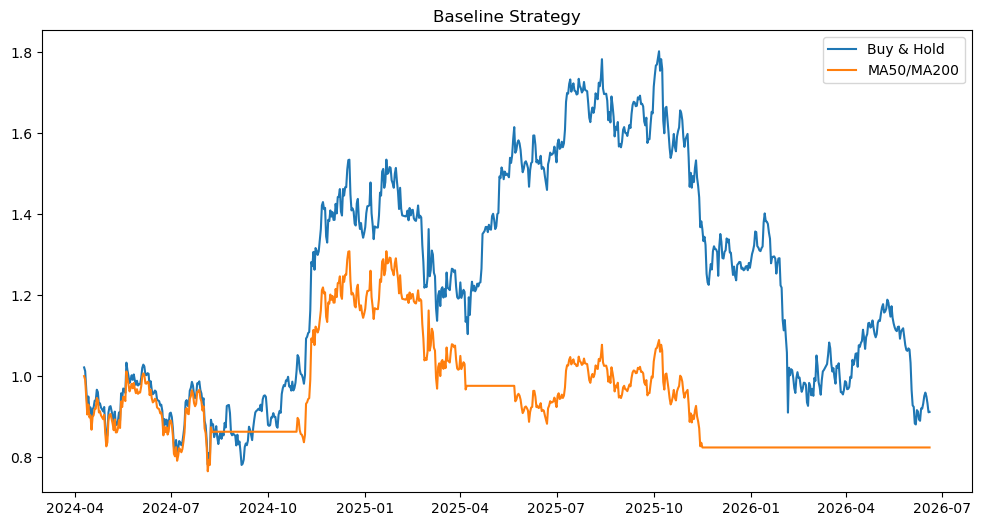

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df["timestamp"],
    df["market_equity"],
    label="Buy & Hold"
)

plt.plot(
    df["timestamp"],
    df["strategy_equity"],
    label="MA50/MA200"
)

plt.legend()

plt.title(
    "Baseline Strategy"
)

plt.show()